# KMeans Clustering on Handwritten Digits

This notebook follows the scikit-learn handwritten digits KMeans example and preserves the complete workflow from the original notebook.  

The notebook performs the following tasks:

- Loads and examines the handwritten-digits dataset.
- Benchmarks K-Means++, random, and PCA-based initialization.
- Reduces the data to two dimensions with Principal Component Analysis.
- Visualizes cluster regions and centroids.
- Runs four additional experiments:
    - Different initialization methods
    - Different numbers of clusters
    - Different random seeds
    - Difficult cluster structures
- Saves all essential plots in `root_folder/plots/handwritten_digits/`.
- Saves all essential result files in `root_folder/results/handwritten_digits/`.

The known digit labels are used only to evaluate the clustering results. They are not supplied to K-Means during model fitting.

### Import Required Libraries

In [1]:
from pathlib import Path
from time import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

##### Explanation :
The required Python libraries are loaded. This cell does not produce a numerical result, but all later cells depend on these important.

### Define the Project Folders

In [2]:
# Current location from which Jupyter is running
CURRENT_DIR = Path.cwd().resolve()


def find_project_root(start_path):
    """
    Search upward until the main project folder is found.

    The project root must contain:
    - data/
    - notebooks/
    - plots/
    - results/
    """

    for folder in [start_path, *start_path.parents]:

        required_folders = [
            folder / "data",
            folder / "notebooks",
            folder / "plots",
            folder / "results",
        ]

        if all(path.is_dir() for path in required_folders):
            return folder

    raise FileNotFoundError(
        "Project root could not be found. "
        "Make sure the project contains data, notebooks, plots, and results folders."
    )


# Find the main project folder
ROOT_DIR = find_project_root(CURRENT_DIR)

# Correct notebook location
NOTEBOOK_PATH = (
    ROOT_DIR
    / "notebooks"
    / "module_2"
    / "01_handwritten_digits.ipynb"
)

# Folder for plots created by this notebook
PLOTS_DIR = (
    ROOT_DIR
    / "plots"
    / "handwritten_digits"
)

# Folder for result files created by this notebook
RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "handwritten_digits"
)

# Create output folders if they do not already exist
PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Random state used throughout the notebook
RANDOM_STATE = 0

print("=" * 100)
print("PROJECT FOLDER CHECK")
print("=" * 100)
print(f"Current directory : {CURRENT_DIR}")
print(f"Project root      : {ROOT_DIR}")
print(f"Notebook path     : {NOTEBOOK_PATH}")
print(f"Notebook exists   : {NOTEBOOK_PATH.exists()}")
print(f"Plots folder      : {PLOTS_DIR}")
print(f"Results folder    : {RESULTS_DIR}")
print(f"Random state      : {RANDOM_STATE}")
print("=" * 100)

PROJECT FOLDER CHECK
Current directory : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Project root      : C:\Users\samsa\Documents\Capstone Project\Project
Notebook path     : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2\01_handwritten_digits.ipynb
Notebook exists   : True
Plots folder      : C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits
Results folder    : C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits
Random state      : 0


##### Explanation :
The printed paths confirm that the notebook recognizes the project root correctly. The two output folders are created automatically if they do not already exist.

### Load the Handwritten-Digits Dataset

In [3]:
data, labels = load_digits(
    return_X_y=True
)

n_samples, n_features = data.shape
n_digits = np.unique(labels).size

print("=" * 100)
print("HANDWRITTEN-DIGITS DATASET")
print("=" * 100)
print(f"Number of unique digits : {n_digits}")
print(f"Number of observations  : {n_samples}")
print(f"Number of features      : {n_features}")
print(f"Feature matrix shape    : {data.shape}")
print(f"Label vector shape      : {labels.shape}")
print(f"Minimum pixel value     : {data.min():.0f}")
print(f"Maximum pixel value     : {data.max():.0f}")
print("=" * 100)

HANDWRITTEN-DIGITS DATASET
Number of unique digits : 10
Number of observations  : 1797
Number of features      : 64
Feature matrix shape    : (1797, 64)
Label vector shape      : (1797,)
Minimum pixel value     : 0
Maximum pixel value     : 16


##### Explanation :
The dataset contains $1797$ observations, $64$ pixel features and $10$ known digit classes. Pixel intensity values range from $0$ to $16$.

### Define the Official Benchmark Function

Create a reusable function that standardizes the features, fits a supplied KMeans estimator, measures fitting time and calculates the benchmark metrics used in the official scikit-learn example.

In [4]:
benchmark_rows = []


def benchmark_kmeans(
    model,
    name,
    X,
    y,
):
    """
    Fit one K-Means configuration and
    store its evaluation metrics.
    """

    start_time = time()

    pipeline = make_pipeline(
        StandardScaler(),
        model,
    )

    pipeline.fit(X)

    fit_time = time() - start_time

    fitted_model = pipeline[-1]
    cluster_labels = fitted_model.labels_

    result = {
        "Initialization": name,
        "Time (seconds)": fit_time,
        "Inertia": fitted_model.inertia_,
        "Homogeneity": metrics.homogeneity_score(
            y,
            cluster_labels,
        ),
        "Completeness": metrics.completeness_score(
            y,
            cluster_labels,
        ),
        "V-Measure": metrics.v_measure_score(
            y,
            cluster_labels,
        ),
        "ARI": metrics.adjusted_rand_score(
            y,
            cluster_labels,
        ),
        "AMI": metrics.adjusted_mutual_info_score(
            y,
            cluster_labels,
        ),
        "Silhouette": metrics.silhouette_score(
            X,
            cluster_labels,
            metric="euclidean",
            sample_size=300,
            random_state=RANDOM_STATE,
        ),
    }

    benchmark_rows.append(result)

    return pipeline

##### Explanation :
The function is now ready to evaluate multiple initialization strategies consistently. No model is fitted until the function is called in the following cells.

### Prepare the Initialization Strategies

Configure KMeans++, random initialization and PCA-based initialization. All models use $10$ clusters becuase the dataset contains 10 known digit classes.

In [5]:
pca_for_initialization = PCA(
    n_components=n_digits
)

pca_for_initialization.fit(data)

benchmark_models = {
    "K-Means++": KMeans(
        init="k-means++",
        n_clusters=n_digits,
        n_init=4,
        random_state=RANDOM_STATE,
    ),
    "Random": KMeans(
        init="random",
        n_clusters=n_digits,
        n_init=4,
        random_state=RANDOM_STATE,
    ),
    "PCA-Based": KMeans(
        init=pca_for_initialization.components_,
        n_clusters=n_digits,
        n_init=1,
    ),
}

##### Explanation :
Three comparable KMeans configurations are prepared. PCA-based initialization is deterministic and therefore uses one initialization while KMeans++ and random initialization use four runs.

### Run the Initialization Benchmark

Fit each configured KMeans model using the benchmark function and store the fitted pipelines for later inspection.

In [6]:
benchmark_pipelines = {}

for method_name, model in benchmark_models.items():

    fitted_pipeline = benchmark_kmeans(
        model=model,
        name=method_name,
        X=data,
        y=labels,
    )

    benchmark_pipelines[
        method_name
    ] = fitted_pipeline

##### Explanation :
All three initialization methods are fitted to the same dataset and evaluated using the same feature preprocessing and metrics. Their results are stored in `benchmark_rows`.

### Organize the Benchmark Results

Convert the collected benchmark records into a pandas DataFrame and arrange the columns in a clear order.

In [7]:
benchmark_columns = [
    "Initialization",
    "Time (seconds)",
    "Inertia",
    "Homogeneity",
    "Completeness",
    "V-Measure",
    "ARI",
    "AMI",
    "Silhouette",
]

benchmark_df = pd.DataFrame(
    benchmark_rows
)

benchmark_df = benchmark_df[
    benchmark_columns
].copy()

##### Explanation :
The results from the three initalization methods are now organized into one structured DataFrame.

### Prepare the Benchmark Display Table

Create a rounded copy of the benchmark table for notebook display. The original DataFrame remains unrounded for saving.

In [8]:
benchmark_display = benchmark_df.round(
    {
        "Time (seconds)": 3,
        "Inertia": 0,
        "Homogeneity": 4,
        "Completeness": 4,
        "V-Measure": 4,
        "ARI": 4,
        "AMI": 4,
        "Silhouette": 4,
    }
)

##### Explanation :
The numerical values are rounded only for easier reading in the notebook. Full-precision values remain available in `benchmark_df`.

### Display the Benchmark Results

Display a professionally formatted comparison table for the three initialization methods.

In [9]:
benchmark_table = (
    benchmark_display.style
    .hide(axis="index")
    .set_caption(
        "Comparison of K-Means Initialization Methods"
    )
    .format(
        {
            "Time (seconds)": "{:.3f}",
            "Inertia": "{:.0f}",
            "Homogeneity": "{:.4f}",
            "Completeness": "{:.4f}",
            "V-Measure": "{:.4f}",
            "ARI": "{:.4f}",
            "AMI": "{:.4f}",
            "Silhouette": "{:.4f}",
        }
    )
)

display(benchmark_table)

Initialization,Time (seconds),Inertia,Homogeneity,Completeness,V-Measure,ARI,AMI,Silhouette
K-Means++,1.758,69545,0.5981,0.6448,0.6206,0.4693,0.6166,0.1558
Random,0.032,69735,0.6808,0.7225,0.7010,0.5741,0.6979,0.1745
PCA-Based,0.010,69513,0.5995,0.6468,0.6222,0.4682,0.6183,0.1568


##### Explanation :
The table compares computational time, within-cluster compactness, cluster separation and agreement between predicted clusters and known digit labels.  

Lower inertia is preferred while higher homogenity, completeness, V-measure, Adjusted Rand Index, Adjusted Mutual Information and Silhouette scores are generally preferred.

### Save the Benchmark Results

Save the complete benchmark DataFrame as a CSV file inside the project results folder.

In [10]:
benchmark_csv_path = (
    RESULTS_DIR
    / "benchmark.csv"
)

benchmark_df.to_csv(
    benchmark_csv_path,
    index=False,
)

print(
    f"Saved: {benchmark_csv_path}"
)

Saved: C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits\benchmark.csv


##### Explanation :
The complete benchmark results are saved as `benchmark.csv`. The file retains the original numerical precision and can be used for later analysis or reporting.

### Reduce the Data to Two PCA Dimensions

Reduce the original $64$ pixel features to two principal components so that the digit observations can be displayed on a two-dimensional graph.

In [11]:
visual_pca = PCA(
    n_components=2
)

reduced_data = visual_pca.fit_transform(
    data
)

print("=" * 100)
print("PCA REDUCTION")
print("=" * 100)
print(
    "Original feature matrix shape : "
    f"{data.shape}"
)
print(
    "Reduced feature matrix shape  : "
    f"{reduced_data.shape}"
)
print(
    "Explained variance ratio      : "
    f"{visual_pca.explained_variance_ratio_}"
)
print(
    "Total explained variance      : "
    f"{visual_pca.explained_variance_ratio_.sum():.4f}"
)
print("=" * 100)

PCA REDUCTION
Original feature matrix shape : (1797, 64)
Reduced feature matrix shape  : (1797, 2)
Explained variance ratio      : [0.14890594 0.13618771]
Total explained variance      : 0.2851


##### Explanation :
The output confirms that PCA changes the feature matrix from $64$ dimensions to $2$ dimensions.  
The total explained variance indicates how much of the original dataset variability is represented by the two principal components.

### Fit KMeans to the PCA-Reduced Data

Fit a $10-$ cluster KMeans++ model directly to the two-dimensional PCA representation. This model is used for the deicision-region visualization.

In [12]:
kmeans_2d = KMeans(
    init="k-means++",
    n_clusters=n_digits,
    n_init=4,
    random_state=RANDOM_STATE,
)

kmeans_2d.fit(
    reduced_data
)

print("=" * 90)
print("TWO-DIMENSIONAL K-MEANS MODEL")
print("=" * 90)
print(
    f"Number of clusters : {kmeans_2d.n_clusters}"
)
print(
    f"Model inertia      : {kmeans_2d.inertia_:.4f}"
)
print(
    "Centroid shape     : "
    f"{kmeans_2d.cluster_centers_.shape}"
)
print("=" * 90)

TWO-DIMENSIONAL K-MEANS MODEL
Number of clusters : 10
Model inertia      : 56261.4907
Centroid shape     : (10, 2)


##### Explanation :  
The model produces $10$ centroids, with each centroid represented by two PCA coordinates. 

The reported inertia is the total squared distance beyween the observations and their assigned centroids in the two-dimensional PCA space.

### Definee the PCA Plot Boundaries

Calculate the minimum and maximum values of the two PCA dimensions and create a dense coordinate grid for the cluster decision regions.

In [13]:
grid_step = 0.02

x_min = reduced_data[:, 0].min() - 1
x_max = reduced_data[:, 0].max() + 1

y_min = reduced_data[:, 1].min() - 1
y_max = reduced_data[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(
        x_min,
        x_max,
        grid_step,
    ),
    np.arange(
        y_min,
        y_max,
        grid_step,
    ),
)

##### Explanation :  
The generated grid covers the completed PCA plot area. Each grid location will be assigned to a cluster to create the colored decision-region background.

### Predict the PCA Decision Regions

Predict the cluster assignment for every location in the dense two-dimensional grid.

In [14]:
grid_points = np.column_stack(
    [
        xx.ravel(),
        yy.ravel(),
    ]
)

grid_labels = kmeans_2d.predict(
    grid_points
)

grid_labels = grid_labels.reshape(
    xx.shape
)

centroids = (
    kmeans_2d.cluster_centers_
)

##### Explanation :
Every grid location receives a cluster label. Reshaping the predictions to the grid dimensions makes it possible to display the KMeans decision regions as an image.

### Visualize the PCA Clusters and Decision Regions

Plot the decision regions, handwritten-digit observations and KMeans centroids. Save the final figure as `pca_clusters.png`.

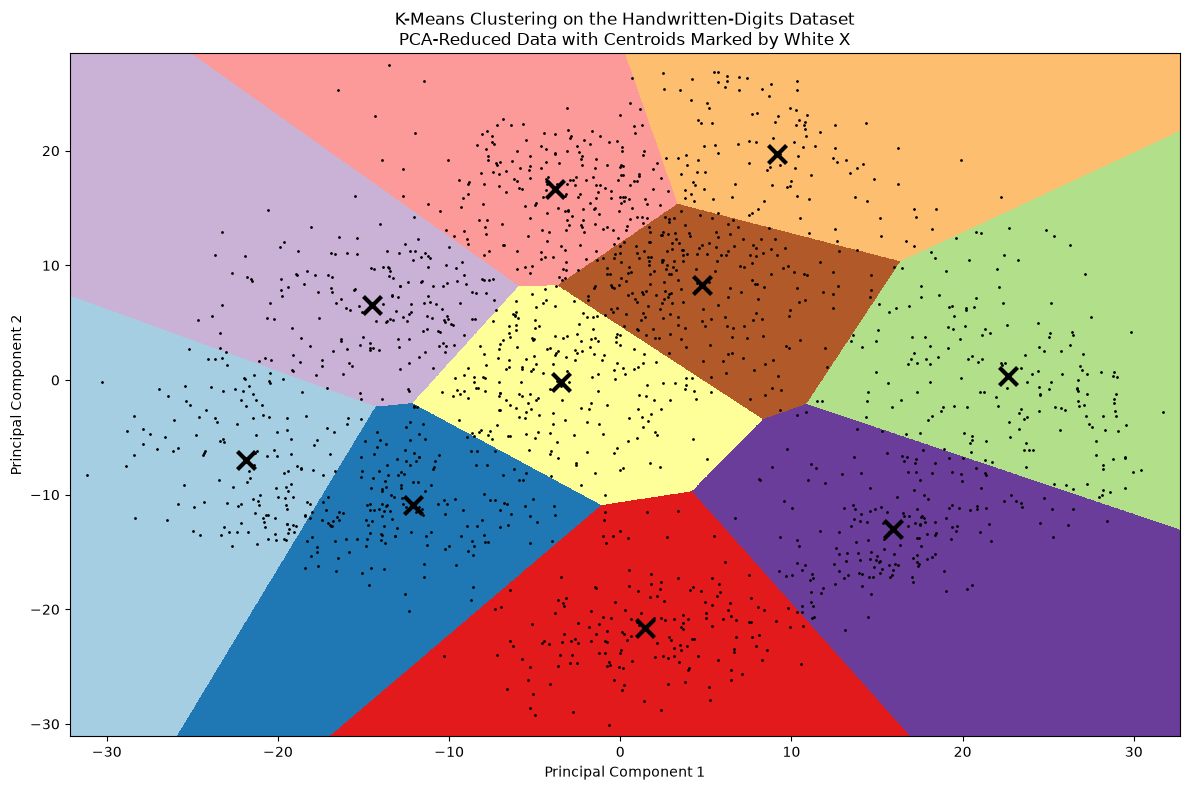

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\pca_clusters.png


In [15]:
plt.figure(
    figsize=(12, 8)
)

plt.imshow(
    grid_labels,
    interpolation="nearest",
    extent=(
        xx.min(),
        xx.max(),
        yy.min(),
        yy.max(),
    ),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(
    reduced_data[:, 0],
    reduced_data[:, 1],
    "k.",
    markersize=2,
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="black",
    zorder=10,
)

plt.title(
    "K-Means Clustering on the Handwritten-Digits Dataset\n"
    "PCA-Reduced Data with Centroids Marked by White X"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.xlim(
    x_min,
    x_max,
)

plt.ylim(
    y_min,
    y_max,
)

plt.tight_layout()

pca_plot_path = (
    PLOTS_DIR
    / "pca_clusters.png"
)

plt.savefig(
    pca_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {pca_plot_path}"
)

##### Explanation :
The colored background shows the region assigned to each cluster. The black points represent handwritten-digit observations after PCA reduction while the black `X` markers represent the $10$ KMeans centroids.  

Overlapping decision regions indicate that the first two principal components do not completely separate all handwritten-digit patterns.

### Save the Main Analysis Summary

Write a text report containing the dataset dimensions, KMeans configuration, PCA information, output locations and benchmark results.

In [16]:
summary_path = (
    RESULTS_DIR
    / "summary.txt"
)

summary_text = f"""
K-MEANS CLUSTERING ON HANDWRITTEN DIGITS
=========================================

Notebook
--------
{NOTEBOOK_PATH}

Dataset
-------
Number of digit classes : {n_digits}
Number of observations  : {n_samples}
Number of features      : {n_features}
Feature matrix shape    : {data.shape}

K-Means Configuration
---------------------
Number of clusters      : {n_digits}
Primary initialization  : k-means++
Number of initial runs  : 4
Random state            : {RANDOM_STATE}

PCA Visualization
-----------------
Original dimensions     : {n_features}
Reduced dimensions      : 2
Total explained variance: {visual_pca.explained_variance_ratio_.sum():.6f}

Output Files
------------
Benchmark CSV : {benchmark_csv_path}
PCA figure    : {pca_plot_path}

Benchmark Results
-----------------
{benchmark_display.to_string(index=False)}
""".strip()

summary_path.write_text(
    summary_text,
    encoding="utf-8",
)

print(summary_text)

print(
    f"\nSaved: {summary_path}"
)

K-MEANS CLUSTERING ON HANDWRITTEN DIGITS

Notebook
--------
C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2\01_handwritten_digits.ipynb

Dataset
-------
Number of digit classes : 10
Number of observations  : 1797
Number of features      : 64
Feature matrix shape    : (1797, 64)

K-Means Configuration
---------------------
Number of clusters      : 10
Primary initialization  : k-means++
Number of initial runs  : 4
Random state            : 0

PCA Visualization
-----------------
Original dimensions     : 64
Reduced dimensions      : 2
Total explained variance: 0.285094

Output Files
------------
Benchmark CSV : C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits\benchmark.csv
PCA figure    : C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\pca_clusters.png

Benchmark Results
-----------------
Initialization  Time (seconds)  Inertia  Homogeneity  Completeness  V-Measure    ARI    AMI  Silhouette
     K-Means++        

##### Explanation :
The text file provides a compact, human-readable record of the main analysis. It also identifies the locations of the saved benchmark results and PCA visualization.

# Additional KMeans Experiments

All full-dimensional KMeans models use the $64$ standardize pixel features. PCA is used only to display the fitted cluster assignments in two dimensions.

### Prepare the Experimental Data

Create separate variables for the original digit features and the known digit labels.

In [17]:
X_raw = data.copy()
y_true = labels.copy()

##### Explanation :
Independent variables are created for the experiment section. This makes the experimental workflow easier to understand without altering the originally loaded dataset

### Standardize the Experimental Features

Standardize all $64$ pixel features so that they have comparable scales during KMeans clustering.

In [18]:
feature_scaler = StandardScaler()

X_scaled = (
    feature_scaler.fit_transform(
        X_raw
    )
)

##### Explanation :
The standardized feature matrix gives each pixel feature a comparable influence on the Euclidean-distance calculations used by KMeans.

### Create PCA Coordinates for the Experiments

Reduce the standardized features to two dimensions for consistent visualization across all experiments.

In [19]:
experiment_pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

X_pca = experiment_pca.fit_transform(
    X_scaled
)

##### Expalantion :
The two-dimensional PCA representation is used only for visualization. The KMeans models in Experiments $1,2$ and $3$ are fitted using all $64$ standardized features.

### Display the Experimental Data Information

Display the dimensions of the original, standardized and PCA-reduced experimental data.

In [20]:
print("=" * 100)
print("EXPERIMENT DATA PREPARATION")
print("=" * 100)
print(
    f"Observations              : {len(X_raw)}"
)
print(
    f"Original features         : {X_raw.shape[1]}"
)
print(
    f"Known digit classes       : {n_digits}"
)
print(
    "Standardized matrix shape : "
    f"{X_scaled.shape}"
)
print(
    "PCA matrix shape          : "
    f"{X_pca.shape}"
)
print(
    "PCA explained variance    : "
    f"{experiment_pca.explained_variance_ratio_.sum():.4f}"
)
print("=" * 100)

EXPERIMENT DATA PREPARATION
Observations              : 1797
Original features         : 64
Known digit classes       : 10
Standardized matrix shape : (1797, 64)
PCA matrix shape          : (1797, 2)
PCA explained variance    : 0.2159


##### Explanation :
The experimental dataset contains the same $1797$ observations and $64$ original features. The PCA matrix contains two coordinates for each observation and is used for plotting.

### Define the Experiment Metric Function

Create a function that calculates internal clustering metrics, external evaluation metrics, fitting time and cluster-size balance.

In [21]:
def calculate_clustering_metrics(
    condition,
    X,
    y,
    cluster_labels,
    model,
    fit_time,
):
    """
    Return internal, external,
    and cluster-size metrics.
    """

    cluster_sizes = np.bincount(
        cluster_labels,
        minlength=model.n_clusters,
    )

    positive_sizes = cluster_sizes[
        cluster_sizes > 0
    ]

    min_size = int(
        positive_sizes.min()
    )

    max_size = int(
        positive_sizes.max()
    )

    sample_size = min(
        1000,
        len(X),
    )

    return {
        "Condition": condition,
        "Clusters": model.n_clusters,
        "Time_seconds": fit_time,
        "Inertia": model.inertia_,
        "Silhouette": metrics.silhouette_score(
            X,
            cluster_labels,
            metric="euclidean",
            sample_size=sample_size,
            random_state=RANDOM_STATE,
        ),
        "Calinski_Harabasz": (
            metrics.calinski_harabasz_score(
                X,
                cluster_labels,
            )
        ),
        "Davies_Bouldin": (
            metrics.davies_bouldin_score(
                X,
                cluster_labels,
            )
        ),
        "Homogeneity": (
            metrics.homogeneity_score(
                y,
                cluster_labels,
            )
        ),
        "Completeness": (
            metrics.completeness_score(
                y,
                cluster_labels,
            )
        ),
        "V_measure": (
            metrics.v_measure_score(
                y,
                cluster_labels,
            )
        ),
        "ARI": (
            metrics.adjusted_rand_score(
                y,
                cluster_labels,
            )
        ),
        "AMI": (
            metrics.adjusted_mutual_info_score(
                y,
                cluster_labels,
            )
        ),
        "Min_cluster_size": min_size,
        "Max_cluster_size": max_size,
        "Size_ratio": (
            max_size / min_size
        ),
    }

##### Explanation :
The function creates one consistent metrics definition for every experimental condition.  

Higher values are preferred for :
- Silhouette Score
- Calinski-Harabasz Score
- Homogeneity
- Completeness
- V-Measure
- Adjusted Rand Index
- Adjusted Mutual Information

Lower values are generally preferred for :
- Inertia
- Davies-Bouldin Score

A cluster-size ratio close to $1$ indicates more evenly sized predicted clusters.

### Define the KMeans Model-Fitting Function

Create a reusable helper that fits one KMeans model, records its running time and calculates the complete metric set.

In [22]:
def fit_kmeans_and_evaluate(
    X,
    y,
    condition,
    **kmeans_parameters,
):
    """
    Fit K-Means and return the
    model, labels, and metrics.
    """

    model = KMeans(
        **kmeans_parameters
    )

    start_time = time()

    cluster_labels = (
        model.fit_predict(X)
    )

    fit_time = (
        time() - start_time
    )

    result = (
        calculate_clustering_metrics(
            condition=condition,
            X=X,
            y=y,
            cluster_labels=cluster_labels,
            model=model,
            fit_time=fit_time,
        )
    )

    return (
        model,
        cluster_labels,
        result,
    )

##### Explanation :
The helper standardizes the fitting process across all experiments and avoids repeating the model-training and metric-calculation code.

### Define the Cluster Plotting Function

Create a reusable plotting function for two-dimensional observations, predicted cluster labels and projected centroids.

In [23]:
def plot_cluster_solution(
    axis,
    points_2d,
    cluster_labels,
    centroids_2d,
    title,
):
    """
    Plot one two-dimensional
    K-Means solution.
    """

    axis.scatter(
        points_2d[:, 0],
        points_2d[:, 1],
        c=cluster_labels,
        cmap="tab20",
        s=12,
        alpha=0.65,
    )

    axis.scatter(
        centroids_2d[:, 0],
        centroids_2d[:, 1],
        marker="X",
        s=180,
        linewidths=1.5,
        edgecolors="black",
        label="Centroids",
    )

    axis.set_title(title)

    axis.set_xlabel(
        "Principal Component 1"
    )

    axis.set_ylabel(
        "Principal Component 2"
    )

    axis.grid(
        alpha=0.2
    )

##### Explanation :
The helper ensures that every cluster visualization uses a consistent coordinate system, marker style, label format and grid layout.

### Define the Display-Table Function

Create a helper that rounds numerical columns before displaying experimental results while leaving the saved DataFrames unrounded.

In [24]:
def prepare_display_table(
    dataframe
):
    """
    Return a rounded copy
    of a results DataFrame.
    """

    display_dataframe = (
        dataframe.copy()
    )

    numeric_columns = (
        display_dataframe.select_dtypes(
            include="number"
        ).columns
    )

    display_dataframe[
        numeric_columns
    ] = display_dataframe[
        numeric_columns
    ].round(4)

    return display_dataframe

##### Explanation :
The display helper improves notebook readability without changing the numerical precision of the CSV result files.

# Experiment 1 : Different Initialization Methods

This experiment compares three centroid initialization methods :
- KMeans++
- Random Initialization
- PCA-based Initialization

All three models use $10$ clusters and all $64$ standardized pixel features.

### Prepare the Experiment 1 Result Containers

Create containers for storing the fitted models, cluster assignments and metrics results.

In [25]:
experiment_1_results = []
experiment_1_models = {}
experiment_1_labels = {}

##### Explanation :
The containers keep the outputs from each initialization method organized for later comparison, visualization and saving.

### Create the PCA-Based Initial Centroids

Use the first $10$ PCA component vectors as the initial centroids for the PCA-based KMeans model.

In [26]:
pca_initial_centroids = PCA(
    n_components=n_digits,
    random_state=RANDOM_STATE,
).fit(
    X_scaled
).components_

##### Explanation :
The resulting array contains $10$ initial centroid vectors, each with $64$ standardized feature values.

### Configure the Experiment 1 Models

Define the KMeans settings for KMeans++, Random Initialization and PCA-based Initialization.

In [27]:
initialization_methods = {
    "K-Means++": {
        "init": "k-means++",
        "n_clusters": n_digits,
        "n_init": 10,
        "random_state": RANDOM_STATE,
    },
    "Random": {
        "init": "random",
        "n_clusters": n_digits,
        "n_init": 10,
        "random_state": RANDOM_STATE,
    },
    "PCA-based": {
        "init": pca_initial_centroids,
        "n_clusters": n_digits,
        "n_init": 1,
    },
}

##### Explanation :
The models differ only in their centroid initialization method. Other important settings remain fixed so that the comparison is controlled.

### Fit the Experiment 1 Models

Fit every initialization method, calculate the complete metric set and store the models and cluster assignments.

In [28]:
for method_name, parameters in (
    initialization_methods.items()
):

    model, cluster_labels, result = (
        fit_kmeans_and_evaluate(
            X=X_scaled,
            y=y_true,
            condition=method_name,
            **parameters,
        )
    )

    experiment_1_models[
        method_name
    ] = model

    experiment_1_labels[
        method_name
    ] = cluster_labels

    experiment_1_results.append(
        result
    )

##### Explanation :
All three models are now fitted using the same standardized dataset. Their models, predicted cluster labels and evaluation metrics are retained for later use.

### Create the Experiment 1 Results Table

Convert the collected metric dictionaries into a pandas DataFrame.

In [29]:
exp1_metrics_df = pd.DataFrame(
    experiment_1_results
)

##### Explanation :
The complete metric results for the three initialization methods are now stored in one structured table.

### Display the Experiment 1 Results

Display the rounded metric table for the three initialization methods.

In [30]:
print(
    "Experiment 1: "
    "Initialization method results"
)

display(
    prepare_display_table(
        exp1_metrics_df
    )
)

Experiment 1: Initialization method results


,Condition,Clusters,Time_seconds,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin,Homogeneity,Completeness,V_measure,ARI,AMI,Min_cluster_size,Max_cluster_size,Size_ratio
0,K-Means++,10,0.0783,69405.4981,0.1502,115.0372,1.8975,0.6031,0.6515,0.6264,0.4679,0.6224,29,421,14.5172
1,Random,10,0.0727,69735.3780,0.1488,113.5538,1.8535,0.6808,0.7225,0.7010,0.5741,0.6979,23,397,17.2609
2,PCA-based,10,0.0102,71018.5056,0.1434,107.9148,2.0118,0.6746,0.7255,0.6991,0.5476,0.6960,32,417,13.0312


##### Explanation :
The table compares the initialization methods using clustering compactness, cluster separation, agreement with known digit labels, computational time and cluster-size balance.

### Visualize the Experiment 1 Cluster Solutions

Project the $64-$ dimensional centroids into the common two-dimensional PCA space and display the three clustering solutions side by side.

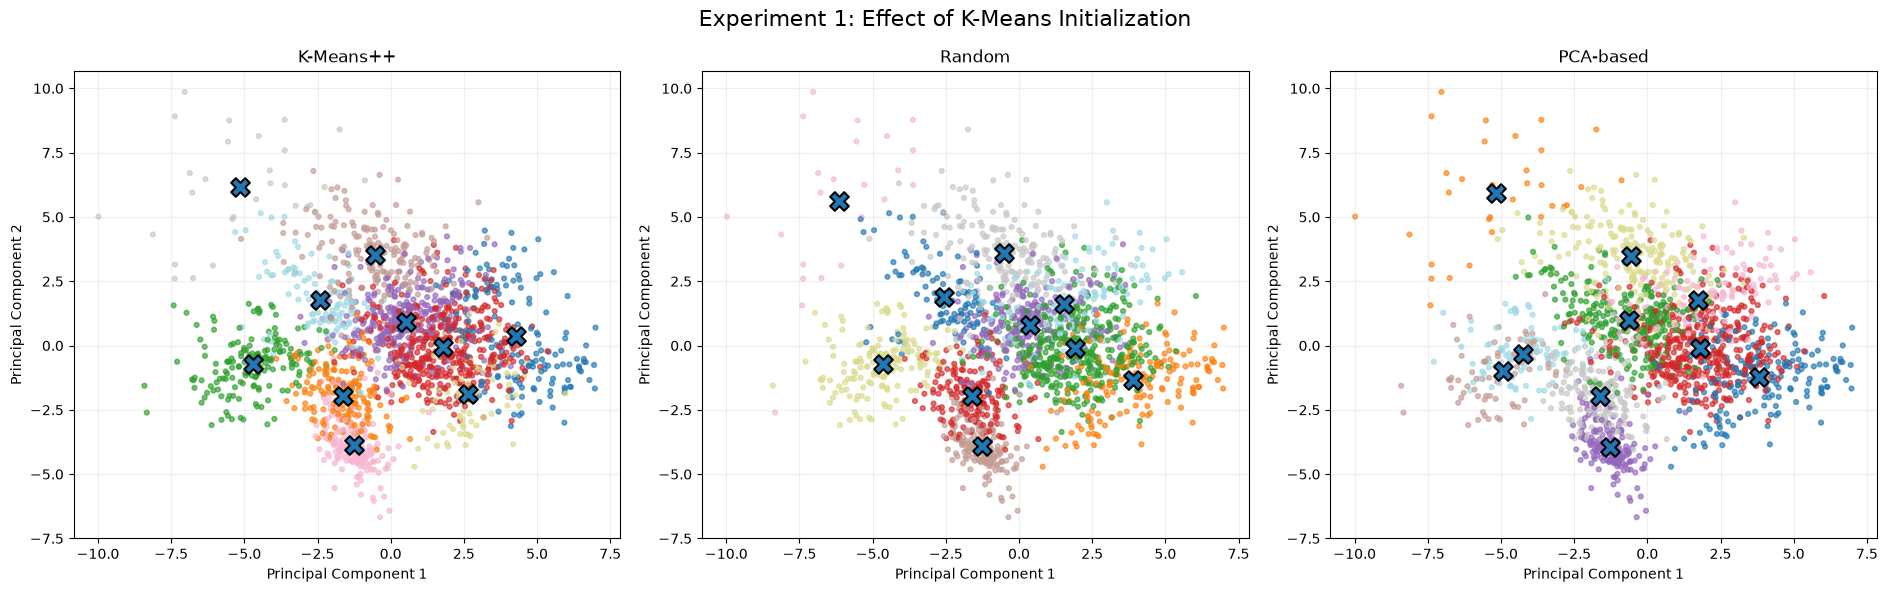

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp1_different_init_clusters.png


In [31]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(19, 6),
)

for axis, method_name in zip(
    axes,
    initialization_methods,
):

    model = experiment_1_models[
        method_name
    ]

    cluster_labels = experiment_1_labels[
        method_name
    ]

    centroids_2d = (
        experiment_pca.transform(
            model.cluster_centers_
        )
    )

    plot_cluster_solution(
        axis=axis,
        points_2d=X_pca,
        cluster_labels=cluster_labels,
        centroids_2d=centroids_2d,
        title=method_name,
    )

fig.suptitle(
    "Experiment 1: "
    "Effect of K-Means Initialization",
    fontsize=16,
)

plt.tight_layout()

exp1_cluster_plot_path = (
    PLOTS_DIR
    / "exp1_different_init_clusters.png"
)

plt.savefig(
    exp1_cluster_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp1_cluster_plot_path}"
)

##### Explanation :
The side-by-side plot shows whether the initialization methods lead to visibly different cluster paritions or centroid locations.  

Similar visual patterns indicate that the methods converged to comparable clustering solutions.

### Prepare the Experiment 1 Key Metrics

Select the primary bounded metrics used for the initialization-method comparison graph.

In [32]:
exp1_key_metrics = (
    exp1_metrics_df
    .set_index("Condition")
    [
        [
            "Silhouette",
            "V_measure",
            "ARI",
            "AMI",
        ]
    ]
)

##### Explanation :
The selected metrics summarize cluster cohension, separation and agreement with the known digit classes. Their values are suitable for direct visual comparison on a common $0$-to-$1$ scale.

### Comapre the Experiment 1 Metrics

Create a grouped bar chart comparing Silhouette,V-measure, ARI and AMI for the three initialization methods.

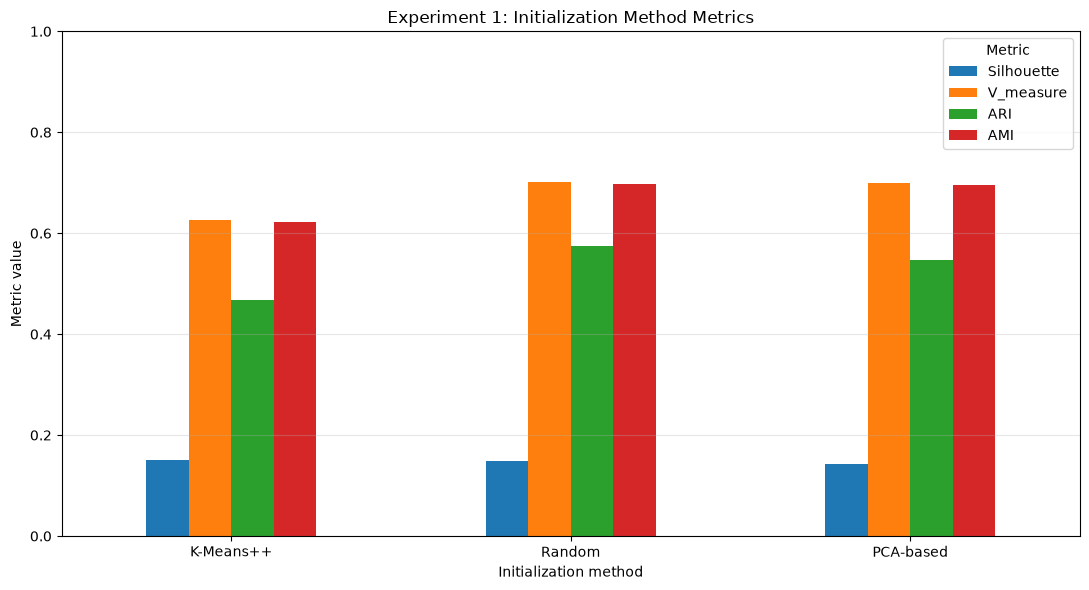

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp1_different_init_metrics.png


In [33]:
axis = exp1_key_metrics.plot(
    kind="bar",
    figsize=(11, 6),
)

axis.set_title(
    "Experiment 1: "
    "Initialization Method Metrics"
)

axis.set_xlabel(
    "Initialization method"
)

axis.set_ylabel(
    "Metric value"
)

axis.set_ylim(
    0,
    1,
)

axis.grid(
    axis="y",
    alpha=0.3,
)

axis.legend(
    title="Metric"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

exp1_metric_plot_path = (
    PLOTS_DIR
    / "exp1_different_init_metrics.png"
)

plt.savefig(
    exp1_metric_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp1_metric_plot_path}"
)

##### Explanation :
Taller bars indicate stronger performance for the displayed metrics. The graph makes differences beyween initialization methods easier to identify than the numerical table alone.

### Save the Experiment 1 Results

Save the complete initialization-method metric table as a CSV file.

In [34]:
exp1_metrics_path = (
    RESULTS_DIR
    / "exp1_different_init_metrics.csv"
)

exp1_metrics_df.to_csv(
    exp1_metrics_path,
    index=False,
)

print(
    f"Saved: {exp1_metrics_path}"
)

Saved: C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits\exp1_different_init_metrics.csv


##### Explanation :
The CSV file stores all Experiment 1 metrics without display rounding and can be used for later reporting or comparison.

# Experiment 2 : Different Number of Clusters

This experiment evaluates the following number of clusters :
$$
k = 2,4,6,8,10,12,14
$$  
The initialization method, feature preprocessing and random seed remain fixed.

### Define the Experiment 2 Cluster Counts

Define the candidate number of clusters that will be evaluated.

In [35]:
K_VALUES = [
    2,
    4,
    6,
    8,
    10,
    12,
    14,
]

##### Explanation :
The selected range includes values below, equal to and above the $10$ known digit classes.

### Prepare the Experiment 2 Result Containers

Create containers for storing the models, predicted labels and metrics associated with each value of $k$.

In [36]:
experiment_2_results = []
experiment_2_models = {}
experiment_2_labels = {}

##### Explanation :
The containers organize the output from each tested cluster count for later analysis and visualization.

### Fit the Experiment 2 Models

Fit one KMeans++ model for every candidate value of $k$

In [37]:
for k in K_VALUES:

    model, cluster_labels, result = (
        fit_kmeans_and_evaluate(
            X=X_scaled,
            y=y_true,
            condition=f"k = {k}",
            init="k-means++",
            n_clusters=k,
            n_init=10,
            random_state=RANDOM_STATE,
        )
    )

    experiment_2_models[
        k
    ] = model

    experiment_2_labels[
        k
    ] = cluster_labels

    experiment_2_results.append(
        result
    )

##### Explanation :
Seven KMeans models are fitted under identical conditions except for the number of clusters.

### Create the Experiment 2 Results Table

Convert the collected metric records into a pandas DataFrame.

In [38]:
exp2_metrics_df = pd.DataFrame(
    experiment_2_results
)

##### Explanation :
The clustering metrics for all seven cluster counts are now organized in one structured table.

### Display the Experiment 2 Results

Display the rounded metric tale for the tested values of $k$.

In [39]:
print(
    "Experiment 2: "
    "Number of clusters results"
)

display(
    prepare_display_table(
        exp2_metrics_df
    )
)

Experiment 2: Number of clusters results


,Condition,Clusters,Time_seconds,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin,Homogeneity,Completeness,V_measure,ARI,AMI,Min_cluster_size,Max_cluster_size,Size_ratio
0,k = 2,2,0.0566,100427.3123,0.0998,164.2530,2.8579,0.2151,0.7806,0.3373,0.1368,0.3362,594,1203,2.0253
1,k = 4,4,0.0654,89113.8681,0.0964,137.5099,2.5108,0.3651,0.6100,0.4568,0.2880,0.4546,358,502,1.4022
2,k = 6,6,0.0703,81695.7688,0.1076,122.4223,2.2409,0.4488,0.6299,0.5242,0.3660,0.5211,33,428,12.9697
3,k = 8,8,0.0701,75181.3066,0.1282,117.0607,1.9832,0.5298,0.6465,0.5823,0.4122,0.5787,29,446,15.3793
4,k = 10,10,0.0754,69405.4981,0.1502,115.0372,1.8975,0.6031,0.6515,0.6264,0.4679,0.6224,29,421,14.5172
5,k = 12,12,0.0824,65115.7250,0.1634,110.9001,1.7323,0.6775,0.6913,0.6843,0.5469,0.6804,4,399,99.7500
6,k = 14,14,0.0912,61747.5673,0.1546,106.3277,1.7029,0.7254,0.6974,0.7111,0.6100,0.7073,1,265,265.0000


##### Explanation :
The table shows how changing the number of clusters affect inertia, cluster separation, agreement with the known digit labels and predicted cluster-size balance.

### Define the Experiment 2 Plot Layout

Calculate the number of rows required to display all candidate cluster solutions in a multi-panel figure.

In [40]:
exp2_columns = 4

exp2_rows = int(
    np.ceil(
        len(K_VALUES)
        / exp2_columns
    )
)

##### Explanation :
The plot will use four columns. The number of rows is calculated automatically from the number of tested cluster counts.

### Visualize the Experiment 2 Cluster Solutions

Display the PCA-projected clustering solution for every tested value of $k$.

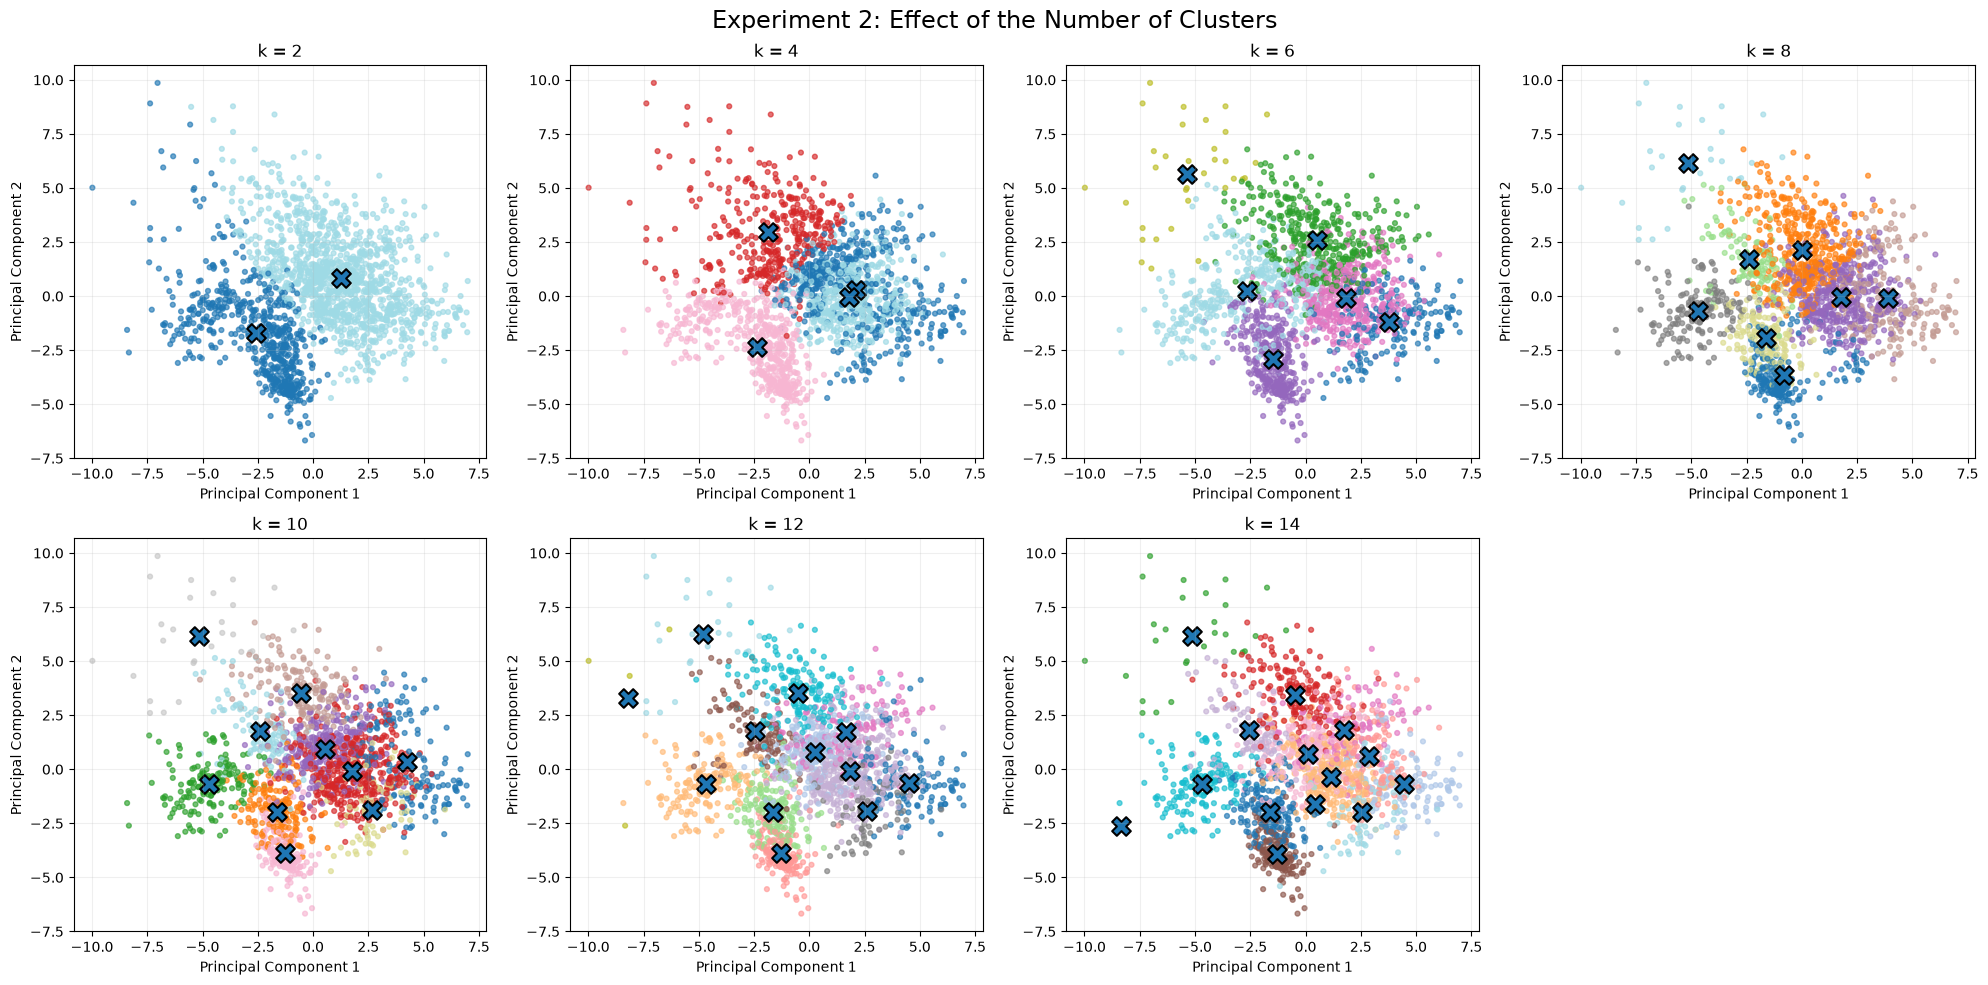

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp2_different_clusters_plot.png


In [41]:
fig, axes = plt.subplots(
    nrows=exp2_rows,
    ncols=exp2_columns,
    figsize=(20, 10),
)

axes = axes.ravel()

for axis, k in zip(
    axes,
    K_VALUES,
):

    model = experiment_2_models[
        k
    ]

    cluster_labels = experiment_2_labels[
        k
    ]

    centroids_2d = (
        experiment_pca.transform(
            model.cluster_centers_
        )
    )

    plot_cluster_solution(
        axis=axis,
        points_2d=X_pca,
        cluster_labels=cluster_labels,
        centroids_2d=centroids_2d,
        title=f"k = {k}",
    )

for axis in axes[
    len(K_VALUES):
]:
    axis.axis("off")

fig.suptitle(
    "Experiment 2: "
    "Effect of the Number of Clusters",
    fontsize=17,
)

plt.tight_layout()

exp2_cluster_plot_path = (
    PLOTS_DIR
    / "exp2_different_clusters_plot.png"
)

plt.savefig(
    exp2_cluster_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp2_cluster_plot_path}"
)

##### Explanation :
Smaller values of $k$ combine several digit patterns into broad clusters. Larger values can divide one digit class into multiple subgroups.  

The plot makes these changes in parition structure and centroid count visible.

### Create the Experiment 2 Elbow Plot

Plot inertia against the number of clusters to identify where the rate of improvement begins to slow.

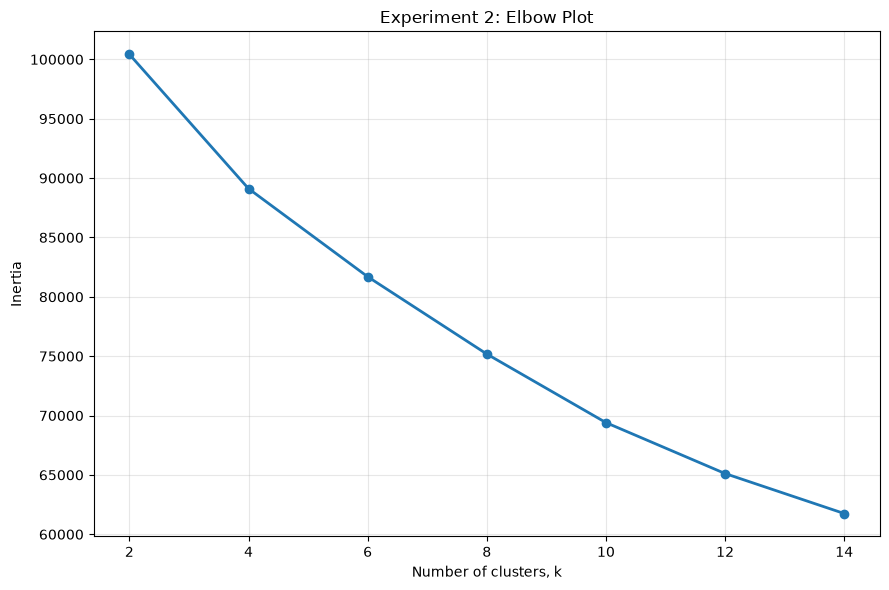

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp2_elbow.png


In [42]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    exp2_metrics_df["Clusters"],
    exp2_metrics_df["Inertia"],
    marker="o",
    linewidth=2,
)

plt.title(
    "Experiment 2: Elbow Plot"
)

plt.xlabel(
    "Number of clusters, k"
)

plt.ylabel(
    "Inertia"
)

plt.xticks(
    K_VALUES
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

exp2_elbow_plot_path = (
    PLOTS_DIR
    / "exp2_elbow.png"
)

plt.savefig(
    exp2_elbow_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp2_elbow_plot_path}"
)

##### Explanation :
Inertial decreases as the number of clusters increases because additional centroids reduce within-cluster distances.  

The important feature is the elbow or bend in the curve, where adding more clusters begins to produce progressively smaller imrpovements.

### Compare the Experiment 2 Quality Metrics

Plot Silhouette, V-measure, Adjusted Rand Index, and Adjusted Mutual Information across the tested cluster counts.

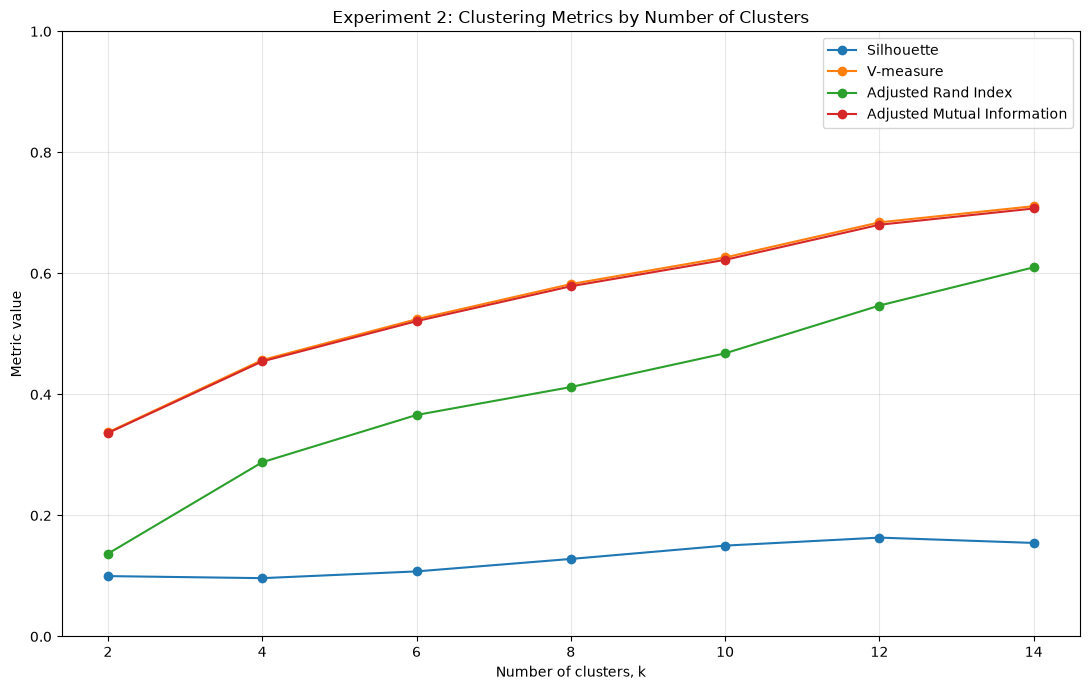

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp2_different_clusters_metrics.png


In [43]:
plt.figure(
    figsize=(11, 7)
)

metric_labels = {
    "Silhouette": "Silhouette",
    "V_measure": "V-measure",
    "ARI": "Adjusted Rand Index",
    "AMI": "Adjusted Mutual Information",
}

for column, label in metric_labels.items():

    plt.plot(
        exp2_metrics_df["Clusters"],
        exp2_metrics_df[column],
        marker="o",
        label=label,
    )

plt.title(
    "Experiment 2: "
    "Clustering Metrics by Number of Clusters"
)

plt.xlabel(
    "Number of clusters, k"
)

plt.ylabel(
    "Metric value"
)

plt.xticks(
    K_VALUES
)

plt.ylim(
    0,
    1,
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

exp2_metric_plot_path = (
    PLOTS_DIR
    / "exp2_different_clusters_metrics.png"
)

plt.savefig(
    exp2_metric_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp2_metric_plot_path}"
)

##### Explanation :
The number of clusters should be evaluated using several criteria rather than inertia alone.  
Because the true digit labels are available in this tutorial, the external metrics can show which value of $k$ most closely reproduces the known digit classes.

### Save the Experiment 2 Results

Save the complete metric table for all tested numbers of clusters.

In [44]:
exp2_metrics_path = (
    RESULTS_DIR
    / "exp2_different_clusters_metrics.csv"
)

exp2_metrics_df.to_csv(
    exp2_metrics_path,
    index=False,
)

print(
    f"Saved: {exp2_metrics_path}"
)

Saved: C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits\exp2_different_clusters_metrics.csv


##### Explanation :
The CSV file provides a complete numerical record of the number-of-clusters experiment for later analysis and reporting.

# Experiment 3: Different Random Seeds

This experiment uses K-Means++ with:

- 10 clusters
- `n_init=1`
- Random seeds `0, 7, 21, 42,` and `99`

Using one initialization intentionally makes the effect of the random starting seed easier to observe.

### Define the Experiment 3 Random Seeds

Define the random seeds that will be used for the stability experiment.

In [45]:
SEEDS = [
    0,
    7,
    21,
    42,
    99,
]

##### Explanation :
Five independent random starting conditions are prepared while all other model settings remain fixed.

### Prepare the Experiment 3 Result Containers

Create containers for storing the seed-specific models, cluster assignments, and metrics.

In [46]:
experiment_3_results = []
experiment_3_models = {}
experiment_3_labels = {}

##### Explanation :
The containers organize the outputs produced under each random seed.

### Fit the Experiment 3 Models

Fit one K-Means model for every random seed using one centroid initialization per seed.

In [47]:
for seed in SEEDS:

    model, cluster_labels, result = (
        fit_kmeans_and_evaluate(
            X=X_scaled,
            y=y_true,
            condition=f"Seed {seed}",
            init="k-means++",
            n_clusters=n_digits,
            n_init=1,
            random_state=seed,
        )
    )

    result[
        "Random_seed"
    ] = seed

    experiment_3_models[
        seed
    ] = model

    experiment_3_labels[
        seed
    ] = cluster_labels

    experiment_3_results.append(
        result
    )

##### Explanation :
Each model begins from a different random initialization. Because `n_init=1`, the model cannot select the best solution from multiple initial runs, making seed-related differences more visible.

### Create the Experiment 3 Results Table

Convert the seed-specific metric records into a pandas DataFrame.

In [48]:
exp3_metrics_df = pd.DataFrame(
    experiment_3_results
)

##### Explanation :
The metrics from all five random seeds are now organized in one table.

### Display the Experiment 3 Results

Display the rounded performance metrics for each random seed.

In [49]:
print(
    "Experiment 3: "
    "Random seed results"
)

display(
    prepare_display_table(
        exp3_metrics_df
    )
)

Experiment 3: Random seed results


,Condition,Clusters,Time_seconds,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin,Homogeneity,Completeness,V_measure,ARI,AMI,Min_cluster_size,Max_cluster_size,Size_ratio,Random_seed
0,Seed 0,10,0.0110,69749.0825,0.1459,113.4925,1.8997,0.6722,0.7199,0.6952,0.5593,0.6920,32,402,12.5625,0
1,Seed 7,10,0.0076,70336.9716,0.1343,110.8843,1.8648,0.5677,0.6360,0.5999,0.4412,0.5956,9,420,46.6667,7
2,Seed 21,10,0.0109,69562.7449,0.1390,114.3284,1.8298,0.6022,0.6805,0.6390,0.4794,0.6352,2,449,224.5000,21
3,Seed 42,10,0.0101,69845.7847,0.1367,113.0604,1.8061,0.6393,0.7083,0.6720,0.5305,0.6686,2,413,206.5000,42
4,Seed 99,10,0.0091,69677.4012,0.1525,113.8135,1.8683,0.6812,0.7207,0.7004,0.5702,0.6973,29,398,13.7241,99


##### Explanation :
Differences between the rows indicate sensitivity to the randomly selected initial centroids.

Greater variation in inertia, external metrics, or cluster-size balance suggests that the model is reaching different local solutions.

### Define the Experiment 3 Plot Layout

Calculate the subplot dimensions needed to display all random-seed clustering solutions.

In [50]:
exp3_columns = 3

exp3_rows = int(
    np.ceil(
        len(SEEDS)
        / exp3_columns
    )
)

##### Explanation :
The seed-specific solutions will be displayed using three columns. The required number of rows is calculated automatically.

### Visualize the Experiment 3 Cluster Solutions

Project the centroids from each seed into the common PCA space and display the five clustering solutions.

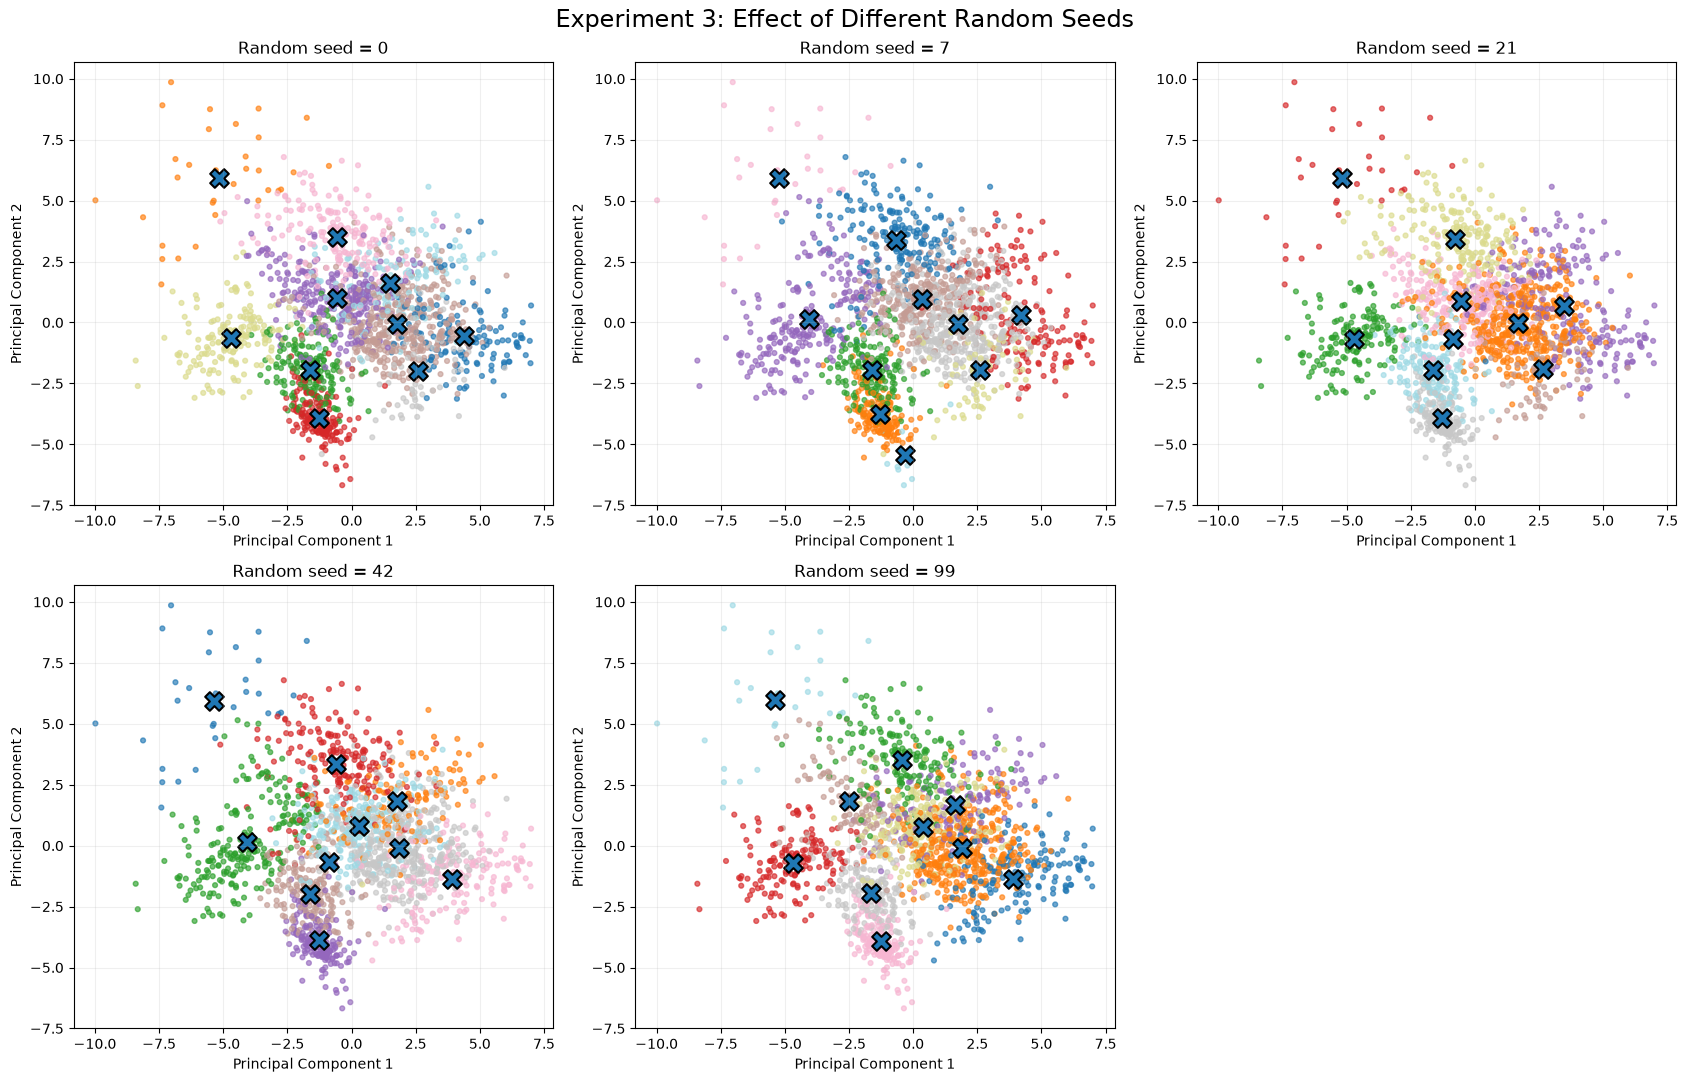

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp3_different_seed_clusters.png


In [51]:
fig, axes = plt.subplots(
    nrows=exp3_rows,
    ncols=exp3_columns,
    figsize=(17, 11),
)

axes = axes.ravel()

for axis, seed in zip(
    axes,
    SEEDS,
):

    model = experiment_3_models[
        seed
    ]

    cluster_labels = experiment_3_labels[
        seed
    ]

    centroids_2d = (
        experiment_pca.transform(
            model.cluster_centers_
        )
    )

    plot_cluster_solution(
        axis=axis,
        points_2d=X_pca,
        cluster_labels=cluster_labels,
        centroids_2d=centroids_2d,
        title=f"Random seed = {seed}",
    )

for axis in axes[
    len(SEEDS):
]:
    axis.axis("off")

fig.suptitle(
    "Experiment 3: "
    "Effect of Different Random Seeds",
    fontsize=17,
)

plt.tight_layout()

exp3_cluster_plot_path = (
    PLOTS_DIR
    / "exp3_different_seed_clusters.png"
)

plt.savefig(
    exp3_cluster_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp3_cluster_plot_path}"
)

##### Explanation :
Visible differences in cluster colors, partition boundaries, or centroid locations show that different random seeds can lead K-Means to different local solutions.

### Initialize the Random-Seed Stability Matrix

Create an empty matrix that will hold pairwise Adjusted Rand Index values between the seed-specific cluster assignments.

In [52]:
seed_stability_matrix = np.zeros(
    (
        len(SEEDS),
        len(SEEDS),
    )
)

##### Explanation :
The square matrix contains one row and one column for every random seed. Each location will measure the agreement between two clustering solutions.

### Calculate the Random-Seed Stability Matrix

Compare every pair of seed-specific cluster assignments using the Adjusted Rand Index.

In [53]:
for row_index, seed_a in enumerate(
    SEEDS
):

    for column_index, seed_b in enumerate(
        SEEDS
    ):

        seed_stability_matrix[
            row_index,
            column_index,
        ] = metrics.adjusted_rand_score(
            experiment_3_labels[
                seed_a
            ],
            experiment_3_labels[
                seed_b
            ],
        )

##### Explanation :
An Adjusted Rand Index close to 1 indicates that two random seeds produced very similar cluster partitions. Lower values indicate that the solutions differ more substantially.

### Create the Seed Stability DataFrame

Convert the pairwise stability matrix into a labeled pandas DataFrame.

In [54]:
seed_stability_df = pd.DataFrame(
    seed_stability_matrix,
    index=[
        f"Seed {seed}"
        for seed in SEEDS
    ],
    columns=[
        f"Seed {seed}"
        for seed in SEEDS
    ],
)

##### Explanation :
The labeled DataFrame makes it easier to identify which random-seed pairs produced similar or different cluster assignments.

### Display the Random-Seed Stability Matrix

Display the pairwise Adjusted Rand Index values rounded to four decimal places.

In [55]:
print(
    "Pairwise Adjusted Rand Index "
    "between seeds"
)

display(
    seed_stability_df.round(4)
)

Pairwise Adjusted Rand Index between seeds


,Seed 0,Seed 7,Seed 21,Seed 42,Seed 99
Seed 0,1.0000,0.7344,0.8416,0.7916,0.8383
Seed 7,0.7344,1.0000,0.7665,0.8168,0.7447
Seed 21,0.8416,0.7665,1.0000,0.7400,0.7368
Seed 42,0.7916,0.8168,0.7400,1.0000,0.9009
Seed 99,0.8383,0.7447,0.7368,0.9009,1.0000


##### Explanation :
The diagonal values equal `1` because each clustering solution is compared with itself.

Off-diagonal values close to `1` indicate highly similar cluster partitions, while lower values indicate greater sensitivity to the initial random seed.

### Visualize the Random-Seed Stability Matrix

Display the pairwise Adjusted Rand Index values as an annotated heatmap.

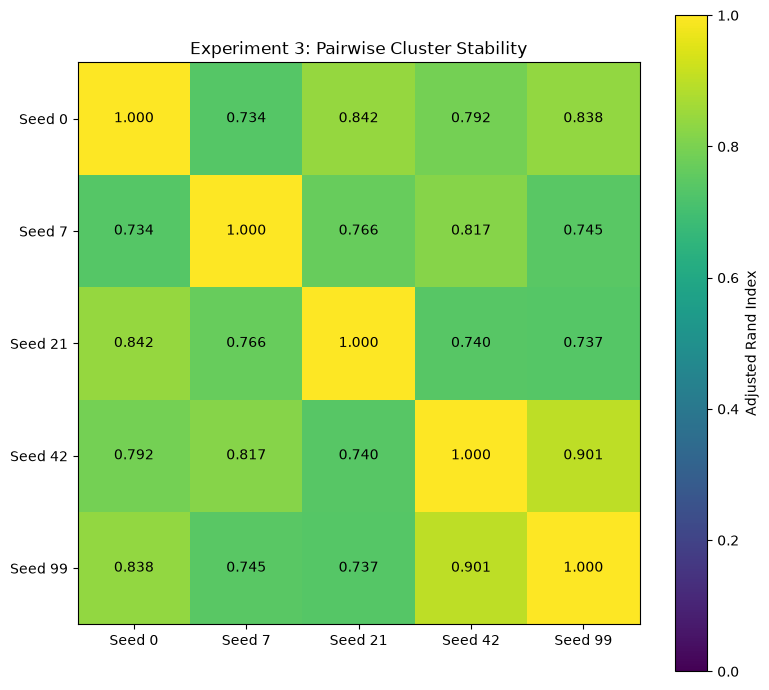

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp3_different_seed_stability.png


In [56]:
fig, axis = plt.subplots(
    figsize=(8, 7)
)

image = axis.imshow(
    seed_stability_matrix,
    vmin=0,
    vmax=1,
    cmap="viridis",
)

axis.set_xticks(
    range(len(SEEDS))
)

axis.set_yticks(
    range(len(SEEDS))
)

axis.set_xticklabels(
    [
        f"Seed {seed}"
        for seed in SEEDS
    ]
)

axis.set_yticklabels(
    [
        f"Seed {seed}"
        for seed in SEEDS
    ]
)

axis.set_title(
    "Experiment 3: "
    "Pairwise Cluster Stability"
)

for row_index in range(
    len(SEEDS)
):

    for column_index in range(
        len(SEEDS)
    ):

        axis.text(
            column_index,
            row_index,
            (
                f"{seed_stability_matrix[row_index, column_index]:.3f}"
            ),
            ha="center",
            va="center",
        )

colorbar = plt.colorbar(
    image,
    ax=axis,
)

colorbar.set_label(
    "Adjusted Rand Index"
)

plt.tight_layout()

exp3_stability_plot_path = (
    PLOTS_DIR
    / "exp3_different_seed_stability.png"
)

plt.savefig(
    exp3_stability_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp3_stability_plot_path}"
)

##### Explanation :
Higher-value cells represent stronger agreement between seed-specific clusterings.

A matrix containing consistently high off-diagonal values indicates that the clustering result remains stable despite different random starting conditions.

### Save the Experiment 3 Metric Results

Save the model-level metrics for the tested random seeds.

In [57]:
exp3_metrics_path = (
    RESULTS_DIR
    / "exp3_different_seed_metrics.csv"
)

exp3_metrics_df.to_csv(
    exp3_metrics_path,
    index=False,
)

print(
    f"Saved: {exp3_metrics_path}"
)

Saved: C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits\exp3_different_seed_metrics.csv


##### Explanation :
The CSV file preserves the performance metrics and cluster-size information for every tested random seed.

### Save the Experiment 3 Stability Matrix

Save the pairwise seed-stability matrix as a separate CSV file.

In [58]:
exp3_stability_path = (
    RESULTS_DIR
    / "exp3_different_seed_stability.csv"
)

seed_stability_df.to_csv(
    exp3_stability_path
)

print(
    f"Saved: {exp3_stability_path}"
)

Saved: C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits\exp3_different_seed_stability.csv


##### Explanation :
The stability CSV file provides a reusable record of the agreement between every pair of random-seed clustering solutions.

# Experiment 4: Difficult Cluster Structures

This experiment creates controlled stress-test versions of the two-dimensional PCA digit representation.

The four conditions are:

- Original PCA structure
- Poorly separated structure
- Unequal-sized digit groups
- Non-spherical structure

These conditions demonstrate important assumptions and limitations of K-Means.

### Create a Reproducible Random Generator

Create a NumPy random-number generator for the modified cluster structures.

In [59]:
experiment_rng = (
    np.random.default_rng(
        RANDOM_STATE
    )
)

##### Explanation :
The random generator ensures that the noise and subsampling operations used in Experiment 4 are reproducible.

### Create the Original Structure Condition

Copy the two-dimensional PCA coordinates and known labels to form the unmodified baseline condition.

In [60]:
X_original_structure = (
    X_pca.copy()
)

y_original_structure = (
    y_true.copy()
)

##### Explanation :
This condition preserves the original standardized PCA geometry and provides a baseline against which the modified structures can be compared.

### Calculate the Global PCA Center
Calculate the overall center of the two-dimensional PCA observations.

In [61]:
global_center = X_pca.mean(
    axis=0
)

##### Explanation :
The global center is used to compress all observations inward when creating the poorly separated condition.

### Create the Poor-Separation Condition

Compress the observations toward the global center and add Gaussian noise to increase overlap between digit groups.

In [62]:
X_poor_separation = (
    global_center
    + 0.35 * (
        X_pca
        - global_center
    )
    + experiment_rng.normal(
        loc=0.0,
        scale=1.6,
        size=X_pca.shape,
    )
)

y_poor_separation = (
    y_true.copy()
)

##### Explanation :
The transformed points should appear more crowded and overlapping than the original PCA structure.

This condition tests K-Means when natural groups are poorly separated and observations from different classes occupy similar regions.

### Define the Unequal-Size Retention Fractions

Define the proportion of observations retained from each known digit class.

In [63]:
digit_fractions = {
    0: 1.00,
    1: 0.90,
    2: 0.80,
    3: 0.70,
    4: 0.60,
    5: 0.50,
    6: 0.40,
    7: 0.30,
    8: 0.20,
    9: 0.10,
}

##### Explanation :
Digit `0` retains all its observations, while progressively smaller fractions are retained for later digit classes. This creates intentional class-size imbalance.

### Initialize the Unequal-Size Index Collection

Create an empty list for the observation indices selected from each digit class.

In [64]:
unequal_indices = []

##### Explanation :
The list will collect the observations retained from each digit class according to the defined fractions.

### Select Unequal Numbers of Digit Observations

Randomly retain a different fraction of observations from each known digit class.

In [65]:
for digit_value, fraction in (
    digit_fractions.items()
):

    digit_indices = np.where(
        y_true == digit_value
    )[0]

    retained_count = max(
        10,
        int(
            len(digit_indices)
            * fraction
        ),
    )

    selected_indices = (
        experiment_rng.choice(
            digit_indices,
            size=retained_count,
            replace=False,
        )
    )

    unequal_indices.extend(
        selected_indices
    )

##### Explanation:
A class-specific subset is selected without replacement. A minimum of 10 observations is retained to ensure that every digit class remains represented.

### Shuffle the Unequal-Size Indices

Convert the selected indices to a NumPy array and shuffle their order.

In [66]:
unequal_indices = np.array(
    unequal_indices
)

experiment_rng.shuffle(
    unequal_indices
)

##### Explanation :
The observations are randomly reordered so that the resulting dataset is not grouped by digit class.

### Create the Unequal-Size Dataset

Use the selected observation indices to create the unequal-sized feature matrix and label vector.

In [67]:
X_unequal_size = X_pca[
    unequal_indices
]

y_unequal_size = y_true[
    unequal_indices
]

##### Explanation :
The resulting dataset contains all 10 digit classes but with intentionally different numbers of observations per class.

This condition tests whether smaller groups are absorbed into larger nearby clusters.

### Center the PCA Coordinates

Subtract the overall mean from each PCA coordinate before applying the nonlinear transformation.

In [68]:
centered_points = (
    X_pca
    - X_pca.mean(axis=0)
)

##### Explanation :
Centering the points simplifies the radial transformation used to create the non-spherical condition.

### Calculate the Radius of Each Observation

Calculate the Euclidean distance of every centered observation from the origin.

In [69]:
radius = np.sqrt(
    centered_points[:, 0] ** 2
    + centered_points[:, 1] ** 2
)

##### Explanation :
The radius determines how strongly each observation will be rotated. Points farther from the center receive a larger rotation.

### Calculate the Nonlinear Twist Angle

Define a rotation angle proportional to each observation’s distance from the center.

In [70]:
twist_angle = (
    0.14
    * radius
)

##### Explanation :
Because the rotation angle changes with distance, the transformation bends the dataset rather than applying one uniform rotation.

### Calculate the Rotation Components

Calculate the cosine and sine values needed to rotate each observation by its individual twist angle.

In [71]:
cos_angle = np.cos(
    twist_angle
)

sin_angle = np.sin(
    twist_angle
)

##### Explanation :
The cosine and sine arrays provide the rotation coefficients for the nonlinear coordinate transformation.

### Transform the First PCA Coordinate

Apply the radial twist transformation to the first PCA coordinate.

In [72]:
twisted_x = (
    centered_points[:, 0]
    * cos_angle
    - centered_points[:, 1]
    * sin_angle
)

##### Explaination :
The first transformed coordinate combines the original PCA coordinates using each observation’s individual rotation angle.

### Transform the Second PCA Coordinate

Apply the radial twist transformation to the second PCA coordinate.

In [73]:
twisted_y = (
    centered_points[:, 0]
    * sin_angle
    + centered_points[:, 1]
    * cos_angle
)

##### Explanation :
The second transformed coordinate completes the nonlinear rotation of every observation.

### Create the Non-Spherical Dataset

Combine the transformed coordinates into a new feature matrix and copy the known digit labels.

In [74]:
X_non_spherical = np.column_stack(
    [
        twisted_x,
        twisted_y,
    ]
)

y_non_spherical = (
    y_true.copy()
)

##### Explanation :
The radial transformation preserves the observations but changes their geometry into curved and irregular patterns.

This condition demonstrates an important K-Means limitation: centroid-based partitions do not represent curved or non-spherical groups naturally.

### Organize the Experiment 4 Conditions

Store the original and modified datasets in a dictionary.

In [75]:
experiment_4_conditions = {
    "Original structure": (
        X_original_structure,
        y_original_structure,
    ),
    "Poor separation": (
        X_poor_separation,
        y_poor_separation,
    ),
    "Unequal size": (
        X_unequal_size,
        y_unequal_size,
    ),
    "Non-spherical": (
        X_non_spherical,
        y_non_spherical,
    ),
}

##### Explanation :
The four experimental conditions are now stored under descriptive names and can be processed using one common fitting loop.

### Create the Experiment 4 Condition-Size Table

Count the number of observations contained in each difficult cluster condition.

In [76]:
condition_sizes = pd.DataFrame(
    {
        "Condition": list(
            experiment_4_conditions
        ),
        "Observations": [
            len(condition_data[0])
            for condition_data
            in experiment_4_conditions.values()
        ],
    }
)

##### Explanation :
The resulting table records the number of observations available in each condition.

### Display the Experiment 4 Condition Sizes

Display the observation count for every difficult cluster structure.

In [77]:
display(
    condition_sizes
)

,Condition,Observations
0,Original structure,1797
1,Poor separation,1797
2,Unequal size,986
3,Non-spherical,1797


##### Explanation :
The original, poor-separation, and non-spherical conditions contain all observations.

The unequal-size condition contains fewer observations because class-specific subsampling was intentionally applied.

### Prepare the Experiment 4 Result Containers

Create containers for the fitted models, predicted labels, standardized condition data, and metric results.

In [78]:
experiment_4_results = []
experiment_4_models = {}
experiment_4_labels = {}
experiment_4_scaled_data = {}

##### Explanation :
The containers keep the outputs from each difficult cluster condition organized.

### Fit K-Means to the Difficult Cluster Conditions

Standardize each condition separately, fit a $10-$cluster K-Means++ model, and calculate the complete evaluation metric set.

In [79]:
for condition_name, (
    condition_X,
    condition_y,
) in experiment_4_conditions.items():

    condition_scaler = (
        StandardScaler()
    )

    condition_X_scaled = (
        condition_scaler.fit_transform(
            condition_X
        )
    )

    model, cluster_labels, result = (
        fit_kmeans_and_evaluate(
            X=condition_X_scaled,
            y=condition_y,
            condition=condition_name,
            init="k-means++",
            n_clusters=n_digits,
            n_init=10,
            random_state=RANDOM_STATE,
        )
    )

    result[
        "Observations"
    ] = len(
        condition_X_scaled
    )

    experiment_4_models[
        condition_name
    ] = model

    experiment_4_labels[
        condition_name
    ] = cluster_labels

    experiment_4_scaled_data[
        condition_name
    ] = condition_X_scaled

    experiment_4_results.append(
        result
    )

##### Explanation :
Each condition is standardized independently before clustering. The results quantify how overlap, class imbalance, and non-spherical geometry influence K-Means performance.

### Create the Experiment 4 Results Table

Convert the difficult-structure metric records into a pandas DataFrame.

In [80]:
exp4_metrics_df = pd.DataFrame(
    experiment_4_results
)

##### Explanation :
The clustering metrics for all four structure conditions are now stored in one table.

### Display the Experiment 4 Results

Display the rounded metric table for the difficult cluster structures.

In [81]:
print(
    "Experiment 4: "
    "Difficult cluster structure results"
)

display(
    prepare_display_table(
        exp4_metrics_df
    )
)

Experiment 4: Difficult cluster structure results


,Condition,Clusters,Time_seconds,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin,Homogeneity,Completeness,V_measure,ARI,AMI,Min_cluster_size,Max_cluster_size,Size_ratio,Observations
0,Original structure,10,0.0782,433.4677,0.3820,1447.8184,0.7894,0.4567,0.4685,0.4625,0.3220,0.4571,61,291,4.7705,1797
1,Poor separation,10,0.0597,568.4348,0.3219,1056.8367,0.8422,0.0807,0.0834,0.0820,0.0289,0.0727,85,312,3.6706,1797
2,Unequal size,10,0.0524,238.5975,0.3701,787.8451,0.8146,0.4826,0.4677,0.4750,0.3399,0.4644,19,150,7.8947,986
3,Non-spherical,10,0.0685,474.5441,0.3548,1305.2539,0.8137,0.4344,0.4472,0.4407,0.2765,0.4350,72,320,4.4444,1797


##### Explanation :
The table quantifies how poor separation, unequal group sizes, and non-spherical geometry affect K-Means.

Declining external metrics indicate weaker recovery of the known digit groups.

### Visualize the Difficult Cluster Structures

Plot the fitted K-Means solution for each stress-test condition.

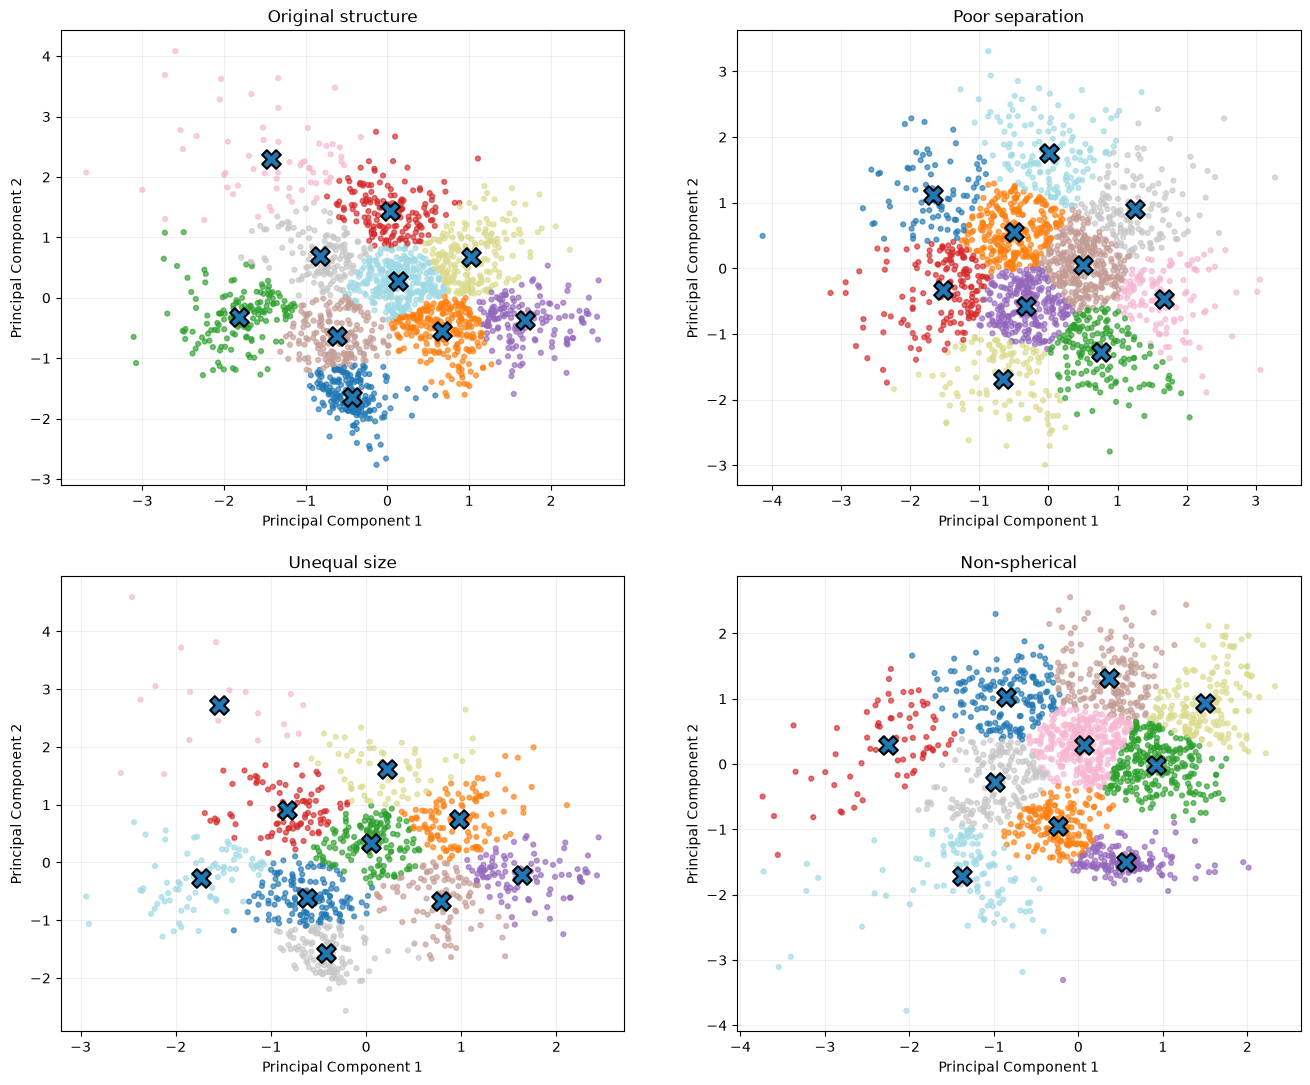

In [82]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 13),
)

axes = axes.ravel()


for axis, condition_name in zip(
    axes,
    experiment_4_conditions,
):

    condition_X_scaled = (
        experiment_4_scaled_data[
            condition_name
        ]
    )

    cluster_labels = (
        experiment_4_labels[
            condition_name
        ]
    )

    model = (
        experiment_4_models[
            condition_name
        ]
    )

    plot_cluster_solution(
        axis=axis,
        points_2d=condition_X_scaled,
        cluster_labels=cluster_labels,
        centroids_2d=model.cluster_centers_,
        title=condition_name,
    )

##### Explanation :
The two-by-two layout allows all four structure conditions to be compared in one figure.

Each subplot displays the standardized observations, predicted cluster assignments, and centroids for one structure condition.

### Save the Difficult-Structure Visualization

Add the main figure title, save the combined plot, and display it.

In [83]:
fig.suptitle(
    "Experiment 4: "
    "Challenging Cluster Structures",
    fontsize=17,
)

plt.tight_layout()

exp4_structure_plot_path = (
    PLOTS_DIR
    / "exp4_different_structures.png"
)

plt.savefig(
    exp4_structure_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp4_structure_plot_path}"
)

<Figure size 640x480 with 0 Axes>

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp4_different_structures.png


##### Explanation :
The figure visually demonstrates important K-Means assumptions.

Compact and separated groups are represented more naturally than overlapping, imbalanced, or curved structures.

### Calculate the Unequal Digit Counts

Count the number of observations retained from each known digit in the unequal-size condition.

In [84]:
unequal_digit_counts = np.bincount(
    y_unequal_size,
    minlength=n_digits,
)

##### Explanation :
The count array contains one value for every digit from 0 through 9 and confirms the number of observations retained in each class.

### Create the Unequal Digit Count Table

Organize the unequal-size digit counts into a pandas DataFrame.

In [85]:
unequal_count_df = pd.DataFrame(
    {
        "Digit": np.arange(
            n_digits
        ),
        "Observations": unequal_digit_counts,
    }
)

##### Explanation :
The DataFrame provides a clear tabular summary of the deliberately imbalanced digit-group sizes.

### Display the Unequal Digit Counts

Display the number of retained observations for every known digit.

In [86]:
display(
    unequal_count_df
)

,Digit,Observations
0,0,178
1,1,163
2,2,141
3,3,128
4,4,108
5,5,91
6,6,72
7,7,53
8,8,34
9,9,18


##### Explanation :
The counts decrease across the digit classes according to the specified retention fractions. This confirms that the intended class imbalance was successfully created.

### Visualize the Unequal Digit Counts

Create a bar graph showing the retained observation count for every digit.

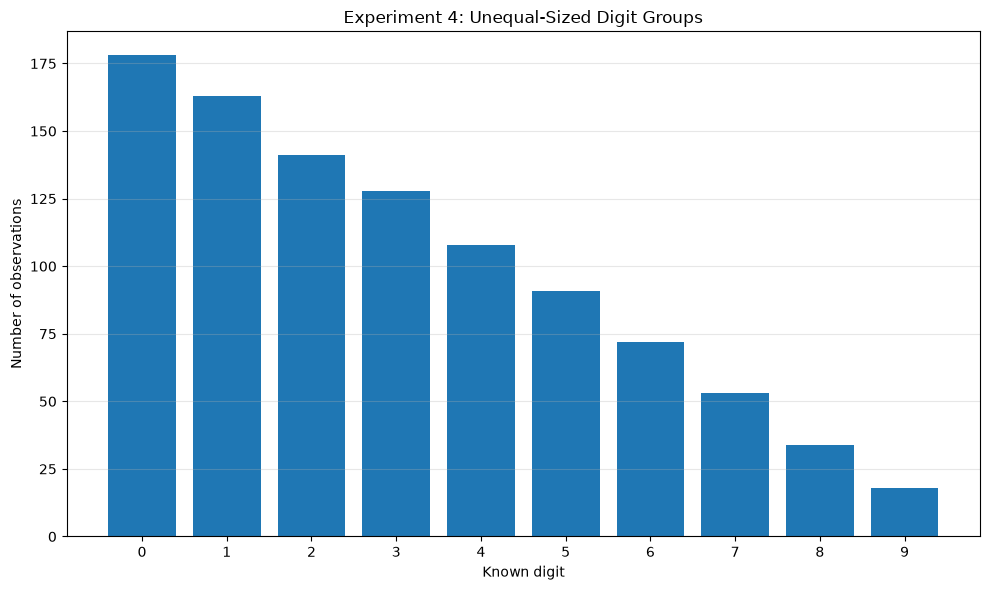

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp4_unequal_counts.png


In [87]:
plt.figure(
    figsize=(10, 6)
)

plt.bar(
    unequal_count_df["Digit"],
    unequal_count_df["Observations"],
)

plt.title(
    "Experiment 4: "
    "Unequal-Sized Digit Groups"
)

plt.xlabel(
    "Known digit"
)

plt.ylabel(
    "Number of observations"
)

plt.xticks(
    range(n_digits)
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

exp4_unequal_plot_path = (
    PLOTS_DIR
    / "exp4_unequal_counts.png"
)

plt.savefig(
    exp4_unequal_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp4_unequal_plot_path}"
)

##### Explanation :
The bar graph makes the deliberate class-size imbalance clear.

Smaller groups contribute less to the K-Means objective and may therefore be represented less effectively than larger groups.

### Prepare the Experiment 4 Key Metrics

Select the main bounded metrics for comparing performance across the four difficult cluster structures.

In [88]:
exp4_key_metrics = (
    exp4_metrics_df
    .set_index("Condition")
    [
        [
            "Silhouette",
            "V_measure",
            "ARI",
            "AMI",
        ]
    ]
)

##### Explanation :
The selected metrics summarize internal cluster separation and agreement with the known digit classes under each structure condition.

### Compare the Experiment 4 Metrics

Create a grouped bar chart comparing Silhouette, V-measure, ARI, and AMI across the four structures.

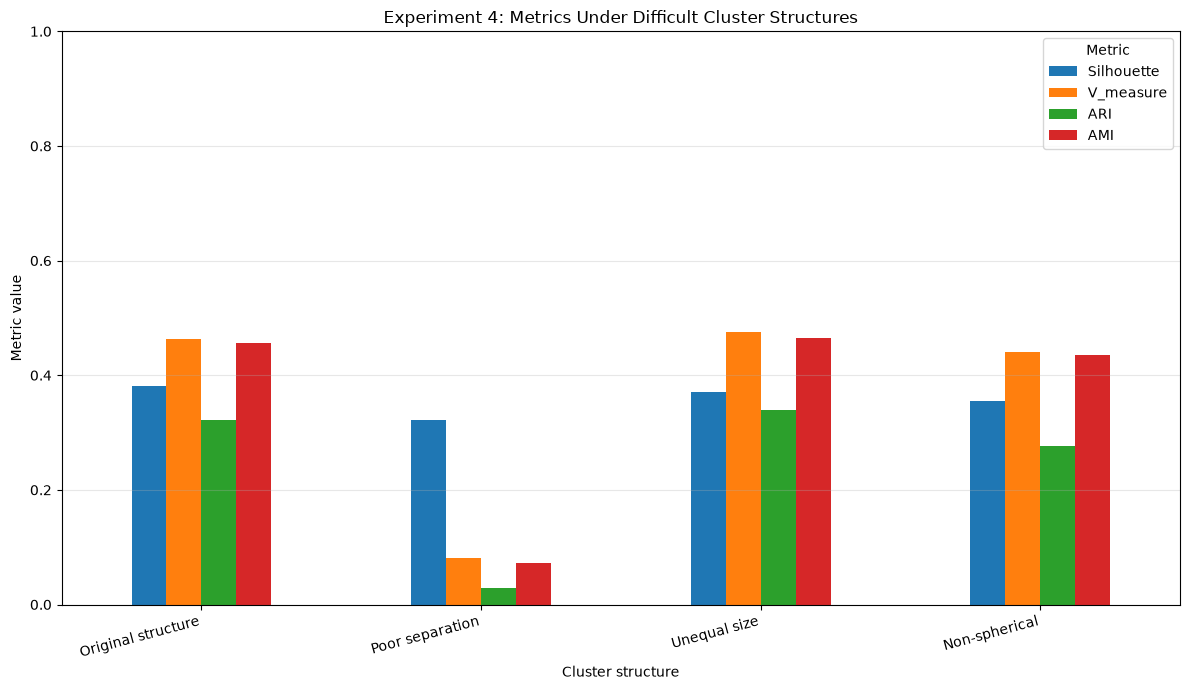

Saved: C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits\exp4_different_structure_metrics.png


In [89]:
axis = exp4_key_metrics.plot(
    kind="bar",
    figsize=(12, 7),
)

axis.set_title(
    "Experiment 4: "
    "Metrics Under Difficult Cluster Structures"
)

axis.set_xlabel(
    "Cluster structure"
)

axis.set_ylabel(
    "Metric value"
)

axis.set_ylim(
    0,
    1,
)

axis.grid(
    axis="y",
    alpha=0.3,
)

axis.legend(
    title="Metric"
)

plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()

exp4_metric_plot_path = (
    PLOTS_DIR
    / "exp4_different_structure_metrics.png"
)

plt.savefig(
    exp4_metric_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {exp4_metric_plot_path}"
)

##### Explanation :
Lower bars under the modified conditions indicate that K-Means has greater difficulty representing overlapping, imbalanced, or non-spherical groups.

The original structure serves as the baseline for interpreting the effect of each modification.

### Save the Experiment 4 Metric Results

Save the complete metric table for the four cluster structures.

In [90]:
exp4_metrics_path = (
    RESULTS_DIR
    / "exp4_different_structure_metrics.csv"
)

exp4_metrics_df.to_csv(
    exp4_metrics_path,
    index=False,
)

print(
    f"Saved: {exp4_metrics_path}"
)

Saved: C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits\exp4_different_structure_metrics.csv


##### Explanation :
The CSV file provides a complete numerical record of the difficult-structure experiment.

### Save the Unequal Digit Counts

Save the retained observation counts from the unequal-size condition as a separate CSV file.

In [91]:
exp4_counts_path = (
    RESULTS_DIR
    / "exp4_unequal_counts.csv"
)

unequal_count_df.to_csv(
    exp4_counts_path,
    index=False,
)

print(
    f"Saved: {exp4_counts_path}"
)

Saved: C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits\exp4_unequal_counts.csv


##### Explanation :
The saved file records the exact number of observations retained from each digit class in the unequal-size condition.

### Display the Main Analysis Output Files

Print the files created by the official handwritten-digits analysis.

In [92]:
print("=" * 90)
print("FILES CREATED")
print("=" * 90)

print("\nMain analysis:")
print(
    f"  {pca_plot_path.name}"
)
print(
    f"  {benchmark_csv_path.name}"
)
print(
    f"  {summary_path.name}"
)

FILES CREATED

Main analysis:
  pca_clusters.png
  benchmark.csv
  summary.txt


##### Explanation :
The main analysis creates one PCA cluster plot, one benchmark CSV file, and one text summary.

### Display the Experiment 1 Output Files

Print the plot and result files created by the initialization-method experiment.

In [93]:
print("\nExperiment 1:")

print(
    f"  {exp1_cluster_plot_path.name}"
)

print(
    f"  {exp1_metric_plot_path.name}"
)

print(
    f"  {exp1_metrics_path.name}"
)


Experiment 1:
  exp1_different_init_clusters.png
  exp1_different_init_metrics.png
  exp1_different_init_metrics.csv


##### Explanation :
Experiment 1 creates a cluster visualization, a metric comparison graph, and a CSV file containing the complete initialization-method results.

### Display the Experiment 2 Output Files

Print the plot and result files created by the number-of-clusters experiment.

In [94]:
print("\nExperiment 2:")

print(
    f"  {exp2_cluster_plot_path.name}"
)

print(
    f"  {exp2_elbow_plot_path.name}"
)

print(
    f"  {exp2_metric_plot_path.name}"
)

print(
    f"  {exp2_metrics_path.name}"
)


Experiment 2:
  exp2_different_clusters_plot.png
  exp2_elbow.png
  exp2_different_clusters_metrics.png
  exp2_different_clusters_metrics.csv


##### Explanation :
Experiment 2 creates a combined cluster plot, an elbow plot, a metric trend plot, and a CSV file containing all tested cluster-count results.

### Display the Experiment 3 Output Files

Print the plot and result files created by the random-seed experiment.

In [95]:
print("\nExperiment 3:")

print(
    f"  {exp3_cluster_plot_path.name}"
)

print(
    f"  {exp3_stability_plot_path.name}"
)

print(
    f"  {exp3_metrics_path.name}"
)

print(
    f"  {exp3_stability_path.name}"
)


Experiment 3:
  exp3_different_seed_clusters.png
  exp3_different_seed_stability.png
  exp3_different_seed_metrics.csv
  exp3_different_seed_stability.csv


##### Explanation :
Experiment 3 creates a seed-specific cluster plot, a stability heatmap, a metric CSV file, and a pairwise stability CSV file.

### Display the Experiment 4 Output Files

Print the plot and result files created by the difficult-cluster-structure experiment.

In [96]:
print("\nExperiment 4:")

print(
    f"  {exp4_structure_plot_path.name}"
)

print(
    f"  {exp4_unequal_plot_path.name}"
)

print(
    f"  {exp4_metric_plot_path.name}"
)

print(
    f"  {exp4_metrics_path.name}"
)

print(
    f"  {exp4_counts_path.name}"
)


Experiment 4:
  exp4_different_structures.png
  exp4_unequal_counts.png
  exp4_different_structure_metrics.png
  exp4_different_structure_metrics.csv
  exp4_unequal_counts.csv


##### Explanation :
Experiment 4 creates a combined difficult-structure plot, an unequal-size count plot, a metric comparison plot, and two CSV result files.

### Display the Output Folder Locations

Print the complete paths of the plot and result folders.

In [97]:
print("\nPlots folder:")
print(PLOTS_DIR)

print("\nResults folder:")
print(RESULTS_DIR)


Plots folder:
C:\Users\samsa\Documents\Capstone Project\Project\plots\handwritten_digits

Results folder:
C:\Users\samsa\Documents\Capstone Project\Project\results\handwritten_digits
